In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
names = [
    'spindale',
    'bovis',
    'japonicum',
    'mattheei',
    'haematobium',
    'guineensis',
    'mekongi',
    'intercalatum',
]

In [3]:
tables = [pd.read_csv(f'{name}.csv') for name in names]

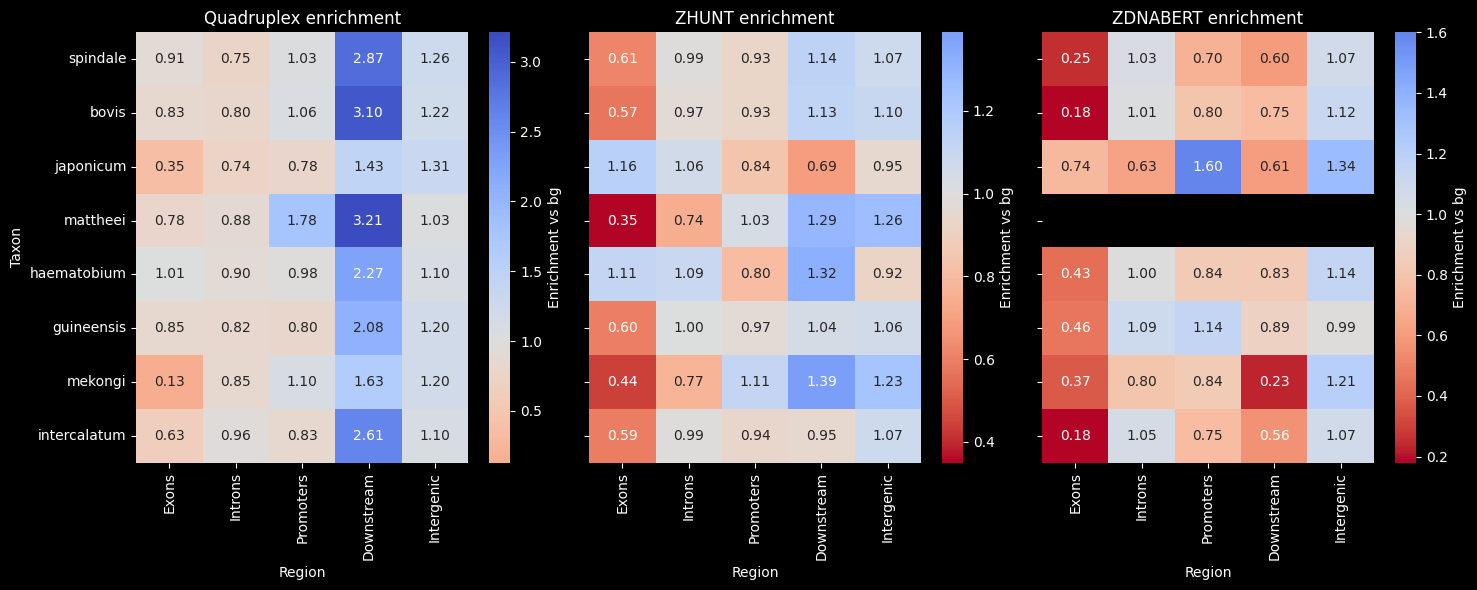

In [17]:
metrics = ['quadruplex_enrichment_vs_bg', 'zhunt_enrichment_vs_bg', 'zdnabert_enrichment_vs_bg']
titles = ['Quadruplex enrichment', 'ZHUNT enrichment', 'ZDNABERT enrichment']

# Get region order from the first table (assumed identical across tables)
regions = tables[0]['Region'].values

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

# Loop over the three metrics
with plt.style.context('dark_background'):
    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        # Build a DataFrame: rows = table_names, columns = regions
        matrix = pd.DataFrame(index=names, columns=regions)
        for i, df in enumerate(tables):
            # Ensure regions are in the same order
            df_sorted = df.set_index('Region').loc[regions]
            if metric in df.columns:
                # Reindex to regions (missing regions become NaN)
                row_vals = df.set_index('Region').reindex(regions)[metric]
            else:
                # Column missing → all NaNs for this row
                row_vals = pd.Series(index=regions, dtype=float)
            matrix.iloc[i, :] = row_vals.values
        matrix = matrix.astype(float)
        
        # Draw heatmap
        hm = sns.heatmap(matrix, annot=True, fmt='.2f', cmap='coolwarm_r', center=1.0,
                    cbar=True, cbar_kws={'label': 'Enrichment vs bg'}, ax=axes[idx])
        # for text in hm.texts:
        #     text.set_color('white')
        ax = hm.axes
        ax.tick_params(colors='white')
        axes[idx].set_title(title, color='white')
        axes[idx].set_xlabel('Region', color='white')
        if idx == 0:
            axes[idx].set_ylabel('Taxon', color='white')
        else:
            axes[idx].set_ylabel('', color='white')

fig.patch.set_facecolor('black')
for ax in axes:
    ax.set_facecolor('black')

plt.tight_layout()
plt.show()